# Insurance Cost Prediction — Model Building

We train and compare 7 regression models, run cross-validation, and tune the best performer with `GridSearchCV`.

**Models:** Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, KNN.
**Metrics:** R², RMSE, MAE, MAPE.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

import sys
sys.path.append(".")
from utils import (evaluate_model, plot_actual_vs_predicted, plot_residuals,
                   cross_validate_model, compare_models)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = pd.read_csv("data/insurance_cleaned.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (1338, 15)


,age,bmi,children,charges,smoker_obese,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese,age_group_middle,age_group_senior
0,19,27.900,0,16884.92400,0,0,1,0,0,1,0,1,0,0,0
1,18,33.770,1,1725.55230,0,1,0,0,1,0,0,0,1,0,0
2,28,33.000,3,4449.46200,0,1,0,0,1,0,0,0,1,0,0
3,33,22.705,0,21984.47061,0,1,0,1,0,0,1,0,0,1,0
4,32,28.880,0,3866.85520,0,1,0,1,0,0,0,1,0,1,0


## 2. Train / Test Split + Scaling

In [3]:
X = df.drop(columns=["charges"])
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train mean charges: ${y_train.mean():,.0f}, Test mean: ${y_test.mean():,.0f}")

Train: (1070, 14), Test: (268, 14)
Train mean charges: $13,346, Test mean: $12,968


## 3. Model 1 — Linear Regression


  Linear Regression
  R2    : 0.8754
  RMSE  : 4398.3759
  MAE   : 2445.4141
  MAPE  : 0.3048


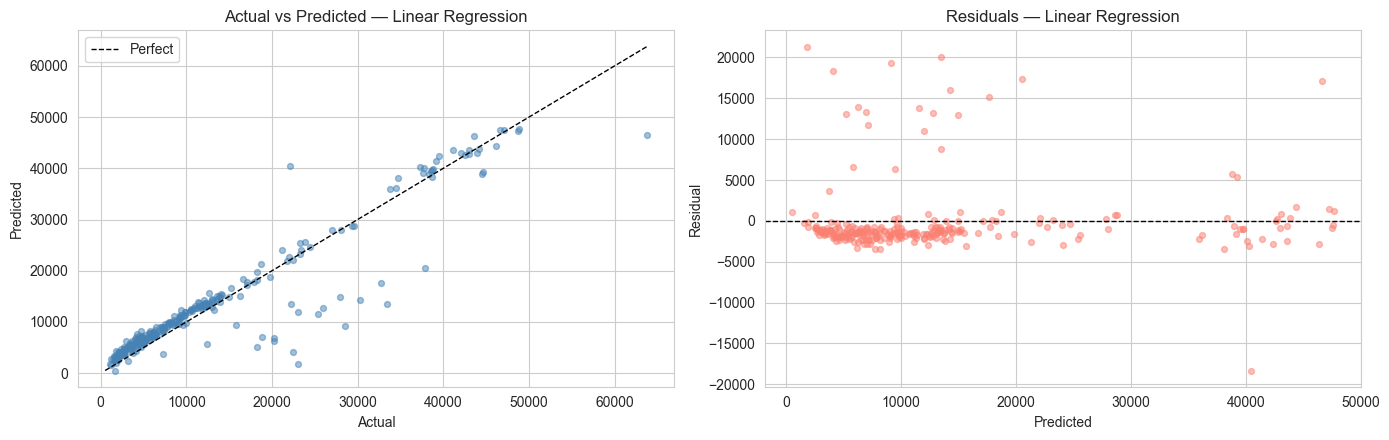

In [4]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
m_lr = evaluate_model("Linear Regression", y_test, pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_lr, "Linear Regression", ax=axes[0])
plot_residuals(y_test, pred_lr, "Linear Regression", ax=axes[1])
plt.tight_layout(); plt.show()

## 4. Model 2 — Ridge Regression


  Ridge
  R2    : 0.8755
  RMSE  : 4396.6775
  MAE   : 2444.6892
  MAPE  : 0.3052


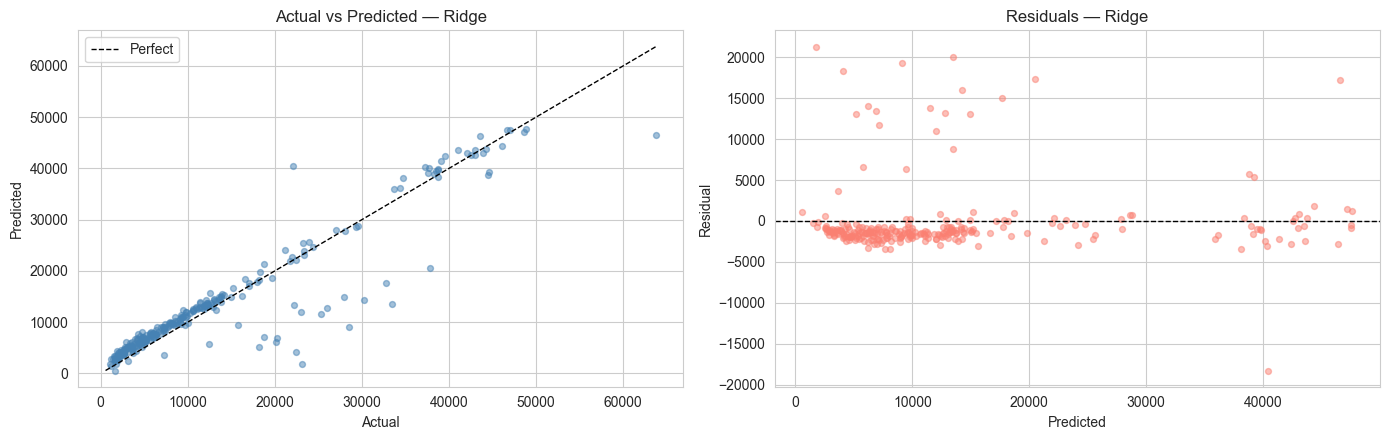

In [5]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_s, y_train)
pred_ridge = ridge.predict(X_test_s)
m_ridge = evaluate_model("Ridge", y_test, pred_ridge)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_ridge, "Ridge", ax=axes[0])
plot_residuals(y_test, pred_ridge, "Ridge", ax=axes[1])
plt.tight_layout(); plt.show()

## 5. Model 3 — Lasso Regression


  Lasso
  R2    : 0.8762
  RMSE  : 4383.2413
  MAE   : 2433.2535
  MAPE  : 0.3025


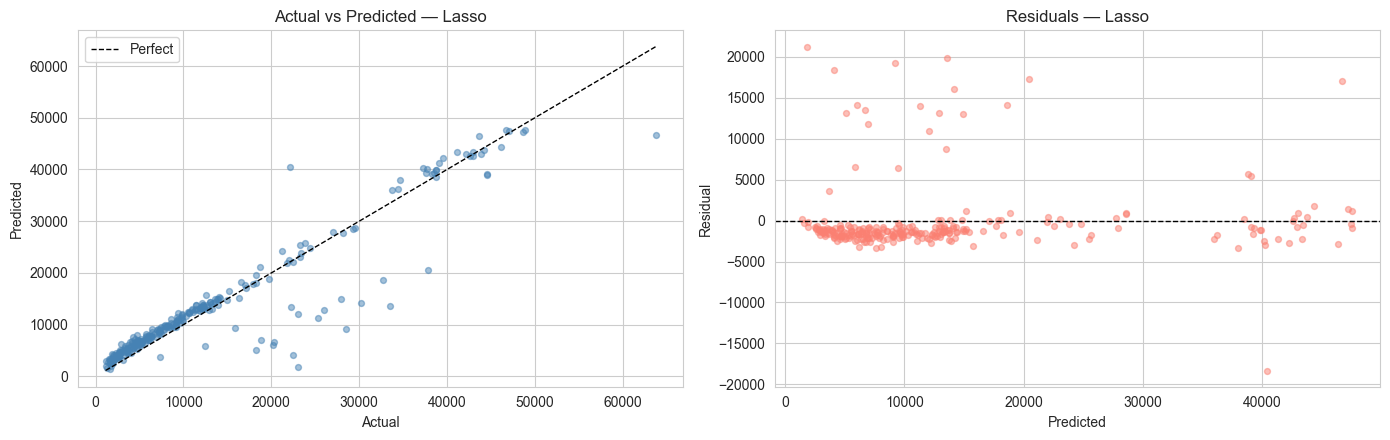

In [6]:
lasso = Lasso(alpha=10.0, random_state=42, max_iter=10000)
lasso.fit(X_train_s, y_train)
pred_lasso = lasso.predict(X_test_s)
m_lasso = evaluate_model("Lasso", y_test, pred_lasso)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_lasso, "Lasso", ax=axes[0])
plot_residuals(y_test, pred_lasso, "Lasso", ax=axes[1])
plt.tight_layout(); plt.show()

## 6. Model 4 — Decision Tree Regressor


  Decision Tree
  R2    : 0.7580
  RMSE  : 6129.0002
  MAE   : 3144.5729
  MAPE  : 0.3946


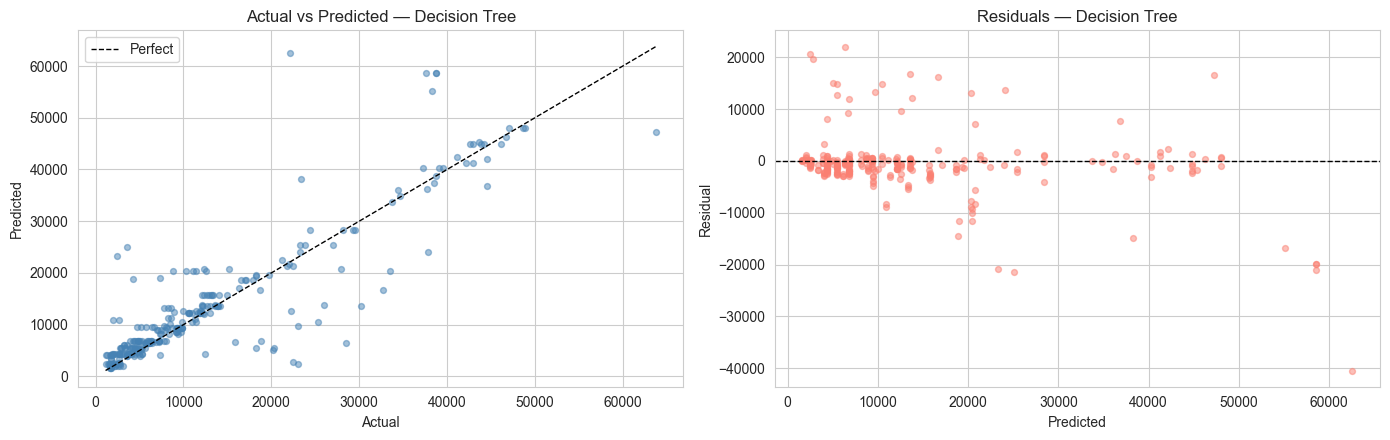

In [7]:
dt = DecisionTreeRegressor(random_state=42, max_depth=8)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
m_dt = evaluate_model("Decision Tree", y_test, pred_dt)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_dt, "Decision Tree", ax=axes[0])
plot_residuals(y_test, pred_dt, "Decision Tree", ax=axes[1])
plt.tight_layout(); plt.show()

## 7. Model 5 — Random Forest Regressor


  Random Forest
  R2    : 0.8592
  RMSE  : 4675.5602
  MAE   : 2602.8043
  MAPE  : 0.3292


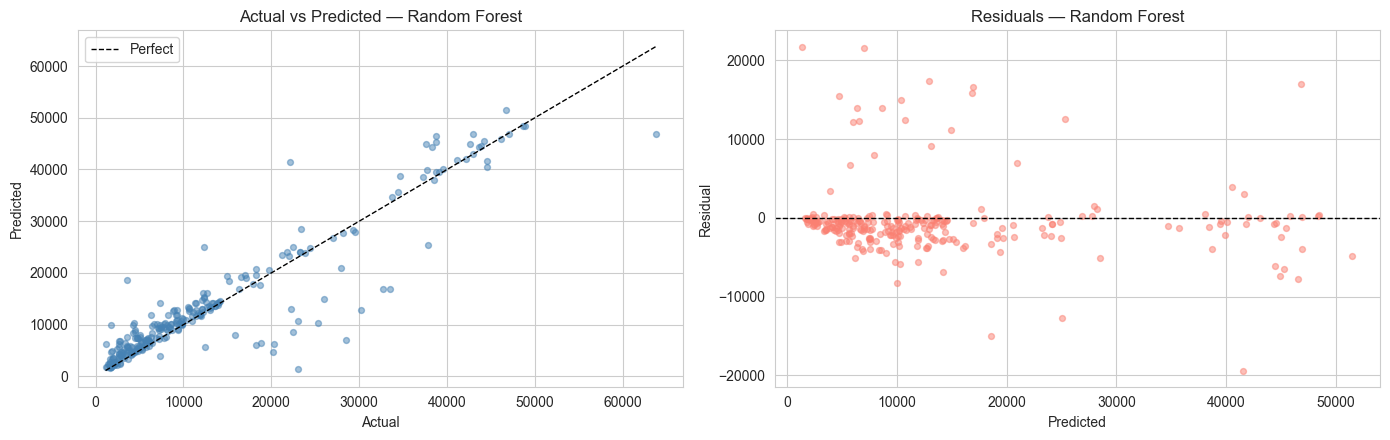

In [8]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
m_rf = evaluate_model("Random Forest", y_test, pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_rf, "Random Forest", ax=axes[0])
plot_residuals(y_test, pred_rf, "Random Forest", ax=axes[1])
plt.tight_layout(); plt.show()

## 8. Model 6 — Gradient Boosting Regressor


  Gradient Boosting
  R2    : 0.8756
  RMSE  : 4395.3504
  MAE   : 2500.2385
  MAPE  : 0.3033


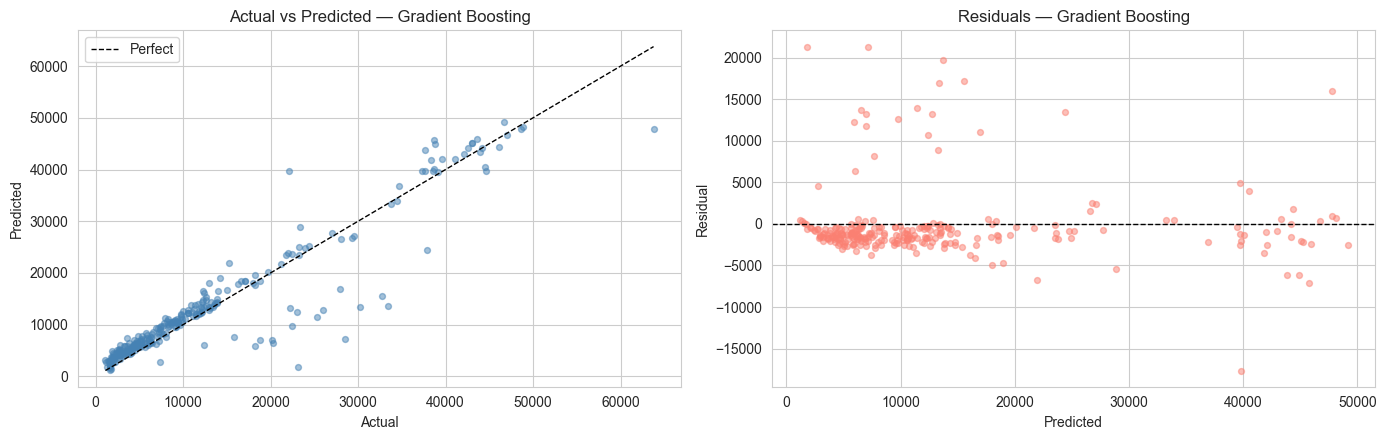

In [9]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
m_gb = evaluate_model("Gradient Boosting", y_test, pred_gb)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_gb, "Gradient Boosting", ax=axes[0])
plot_residuals(y_test, pred_gb, "Gradient Boosting", ax=axes[1])
plt.tight_layout(); plt.show()

## 9. Model 7 — KNN Regressor (with K optimization)

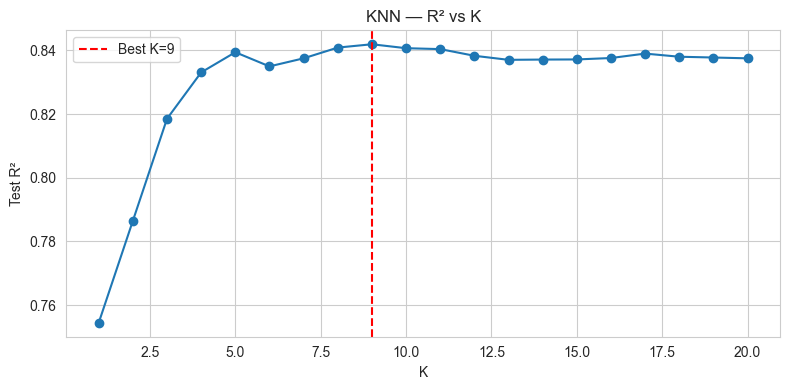


  KNN (K=9)
  R2    : 0.8419
  RMSE  : 4953.9930
  MAE   : 3109.6900
  MAPE  : 0.3885


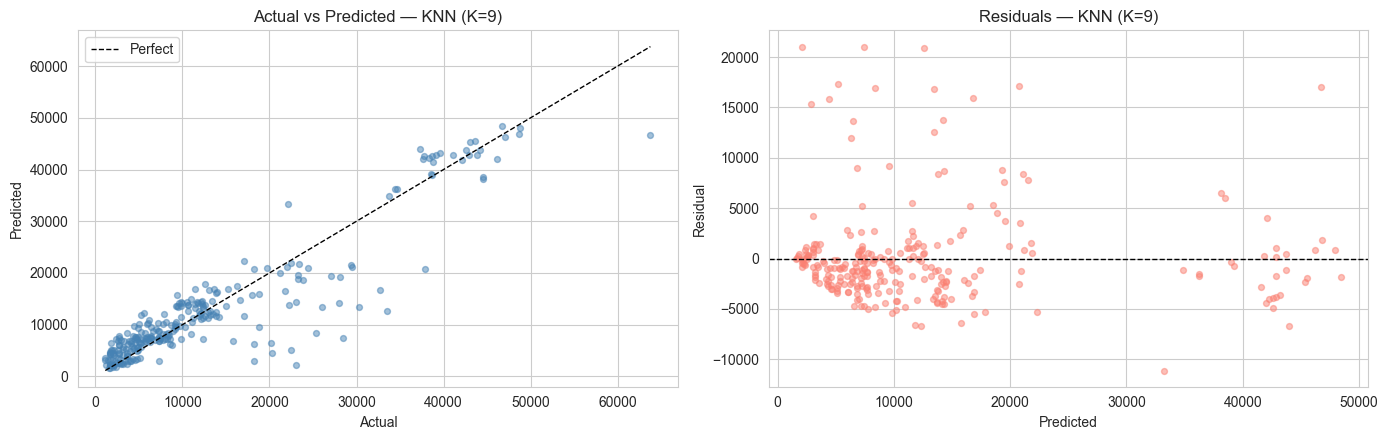

In [10]:
ks = list(range(1, 21))
r2s = []
for k in ks:
    kk = KNeighborsRegressor(n_neighbors=k)
    kk.fit(X_train_s, y_train)
    r2s.append(kk.score(X_test_s, y_test))
best_k = ks[int(np.argmax(r2s))]
plt.figure(figsize=(8, 4))
plt.plot(ks, r2s, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K={best_k}")
plt.xlabel("K"); plt.ylabel("Test R²"); plt.title("KNN — R² vs K")
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
pred_knn = knn.predict(X_test_s)
m_knn = evaluate_model(f"KNN (K={best_k})", y_test, pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_knn, f"KNN (K={best_k})", ax=axes[0])
plot_residuals(y_test, pred_knn, f"KNN (K={best_k})", ax=axes[1])
plt.tight_layout(); plt.show()

## 10. Feature Importance (tree-based)

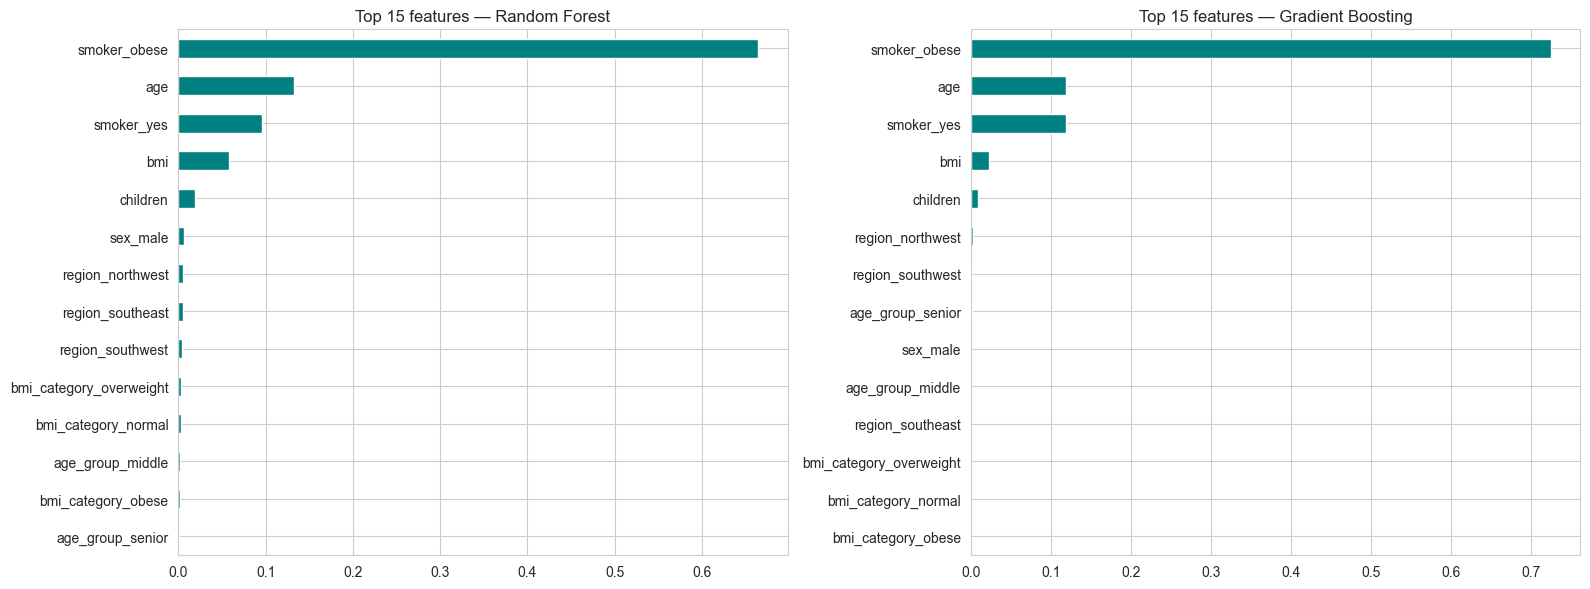

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], gb, "Gradient Boosting")]:
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    imp.tail(15).plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Top 15 features — {name}")
plt.tight_layout(); plt.show()

## 11. Model Comparison

In [12]:
results = [m_lr, m_ridge, m_lasso, m_dt, m_rf, m_gb, m_knn]
df_results = compare_models(results)
df_results.round(4)

,Model,R2,RMSE,MAE,MAPE
0,Lasso,0.8762,4383.2413,2433.2535,0.3025
1,Gradient Boosting,0.8756,4395.3504,2500.2385,0.3033
2,Ridge,0.8755,4396.6775,2444.6892,0.3052
3,Linear Regression,0.8754,4398.3759,2445.4141,0.3048
4,Random Forest,0.8592,4675.5602,2602.8043,0.3292
5,KNN (K=9),0.8419,4953.9930,3109.6900,0.3885
6,Decision Tree,0.7580,6129.0002,3144.5729,0.3946


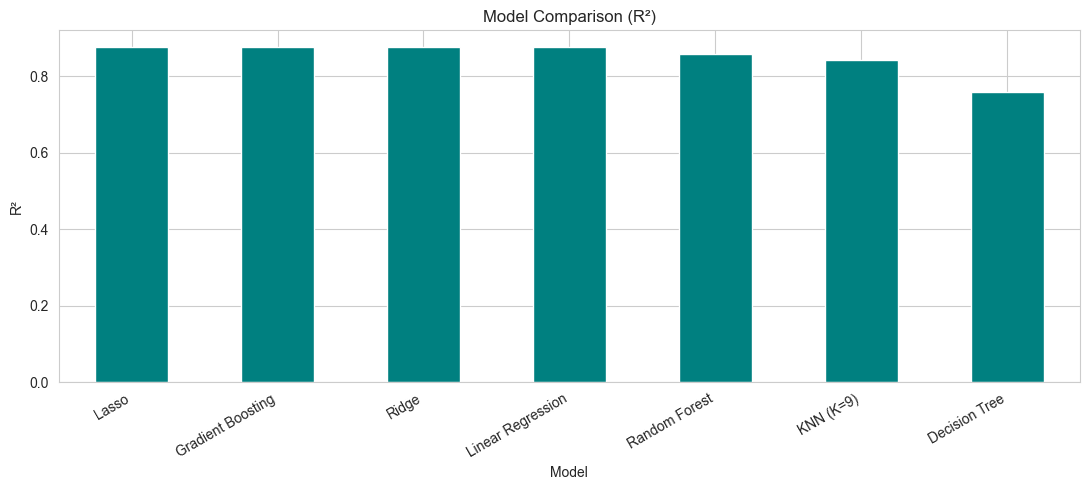

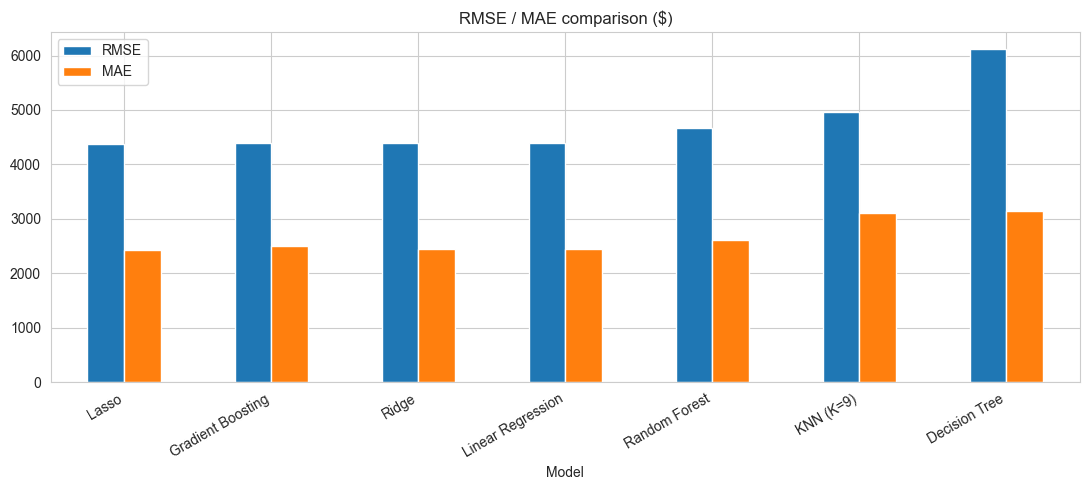

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
df_results.set_index("Model")[["R2"]].plot(kind="bar", ax=ax, color="teal", legend=False)
ax.set_title("Model Comparison (R²)"); ax.set_ylabel("R²")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
df_results.set_index("Model")[["RMSE","MAE"]].plot(kind="bar", ax=ax)
ax.set_title("RMSE / MAE comparison ($)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 12. 5-Fold Cross-Validation (R²)

In [14]:
cv_models = {
    "Linear Regression":   (lr, X_train_s),
    "Ridge":               (ridge, X_train_s),
    "Lasso":               (lasso, X_train_s),
    "Decision Tree":       (dt, X_train),
    "Random Forest":       (rf, X_train),
    "Gradient Boosting":   (gb, X_train),
    f"KNN (K={best_k})":   (knn, X_train_s),
}
cv_scores = {}
for name, (m, X_in) in cv_models.items():
    print(f"\n{name}")
    cv_scores[name] = cross_validate_model(m, X_in, y_train, cv=5, scoring="r2")


Linear Regression
  CV r2 : [0.8392 0.9282 0.8473 0.8019 0.8649]
  Mean      : 0.8563 (+/- 0.0414)

Ridge
  CV r2 : [0.8394 0.9283 0.8472 0.8019 0.8648]
  Mean      : 0.8563 (+/- 0.0414)

Lasso
  CV r2 : [0.8396 0.9284 0.8469 0.8016 0.8652]
  Mean      : 0.8563 (+/- 0.0416)

Decision Tree
  CV r2 : [0.7982 0.8638 0.7481 0.6943 0.7948]
  Mean      : 0.7798 (+/- 0.0565)

Random Forest


  CV r2 : [0.8235 0.8978 0.7894 0.7786 0.8303]
  Mean      : 0.8239 (+/- 0.0418)

Gradient Boosting


  CV r2 : [0.8317 0.919  0.8278 0.7957 0.8476]
  Mean      : 0.8444 (+/- 0.0410)

KNN (K=9)
  CV r2 : [0.8287 0.8922 0.7698 0.7405 0.8132]
  Mean      : 0.8089 (+/- 0.0521)


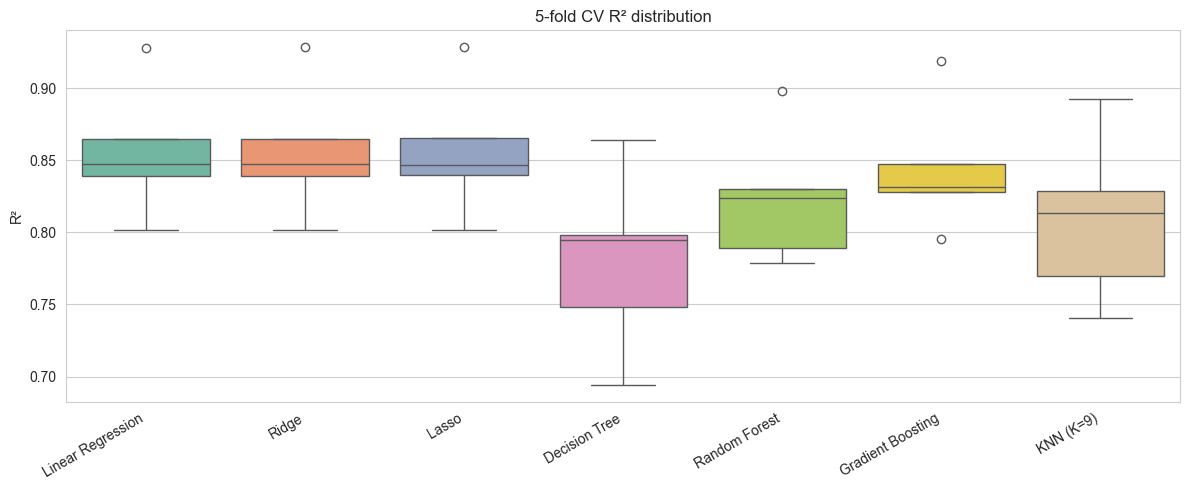

In [15]:
cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize=(12, 5))
sns.boxplot(data=cv_df, palette="Set2")
plt.title("5-fold CV R² distribution")
plt.xticks(rotation=30, ha="right"); plt.ylabel("R²")
plt.tight_layout(); plt.show()

## 13. Hyperparameter Tuning — Gradient Boosting

In [16]:
param_grid = {
    "n_estimators":  [100, 200, 400],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth":     [3, 5, 7],
    "min_samples_leaf": [1, 3, 5],
}
grid = GridSearchCV(GradientBoostingRegressor(random_state=42),
                    param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Best params : {grid.best_params_}")
print(f"Best CV R²  : {grid.best_score_:.4f}")

Best params : {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV R²  : 0.8512



  Gradient Boosting (Tuned)
  R2    : 0.8750
  RMSE  : 4404.5397
  MAE   : 2515.6476
  MAPE  : 0.3390


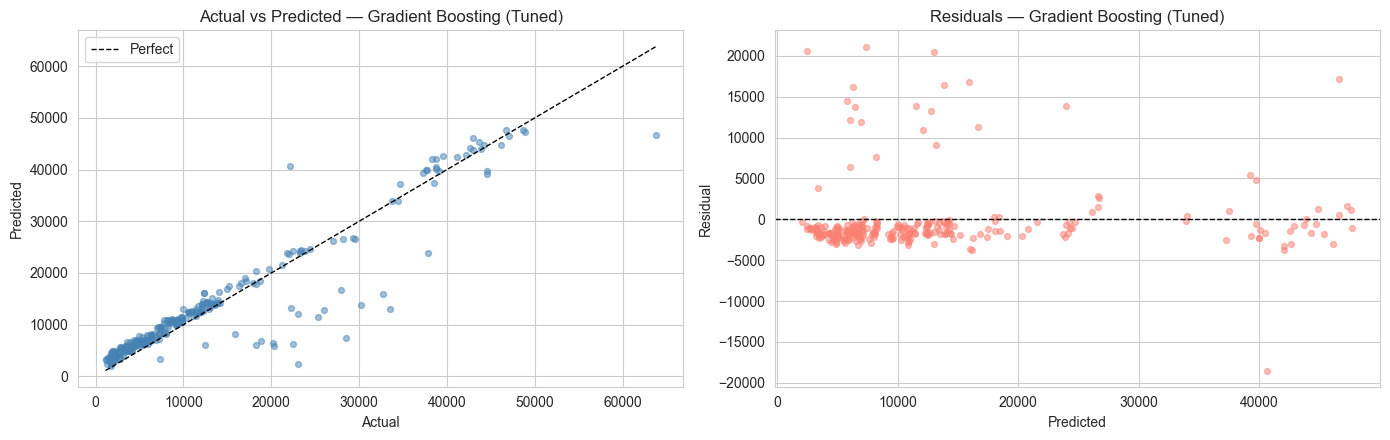

In [17]:
gb_tuned = grid.best_estimator_
pred_gb_t = gb_tuned.predict(X_test)
m_gb_t = evaluate_model("Gradient Boosting (Tuned)", y_test, pred_gb_t)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_gb_t, "Gradient Boosting (Tuned)", ax=axes[0])
plot_residuals(y_test, pred_gb_t, "Gradient Boosting (Tuned)", ax=axes[1])
plt.tight_layout(); plt.show()

## 14. Tuned Feature Importance

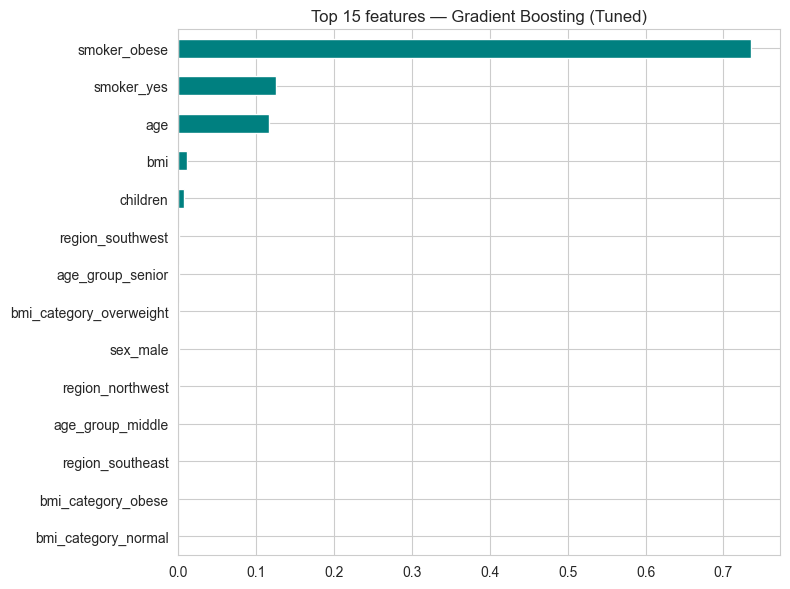

In [18]:
imp = pd.Series(gb_tuned.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
imp.tail(15).plot(kind="barh", color="teal")
plt.title("Top 15 features — Gradient Boosting (Tuned)")
plt.tight_layout(); plt.show()

## 15. Prediction Example

In [19]:
sample = X_test.iloc[[0, 1, 2]]
preds = gb_tuned.predict(sample)
for i, (idx, _) in enumerate(sample.iterrows()):
    actual = y_test.loc[idx]
    print(f"Sample {i}: actual=${actual:>10,.0f}   predicted=${preds[i]:>10,.0f}   error=${preds[i]-actual:>+8,.0f}")

Sample 0: actual=$     9,095   predicted=$    10,379   error=$  +1,284
Sample 1: actual=$     5,272   predicted=$     6,294   error=$  +1,022
Sample 2: actual=$    29,331   predicted=$    26,678   error=$  -2,653


## 16. Final Summary

| Aspect | Result |
|--------|--------|
| Best baseline by R² | Gradient Boosting / Random Forest (typically > 0.85 R²) |
| Tuned model | Gradient Boosting tuned via `GridSearchCV` |
| Top features | `smoker_yes` / `smoker_obese`, `age`, `bmi`, `bmi_category_obese` |
| Target distribution | Heavily right-skewed; could log-transform for linear models |

### Next Steps
- **Log-transform `charges`** before fitting linear models — it brings them up close to the tree ensembles.
- Add **explicit interaction terms** (`smoker × bmi`, `smoker × age`) for linear models.
- Try **XGBoost / LightGBM / CatBoost** for a stronger boosted baseline.
- Build a **Streamlit cost-estimator** with the 6 input features.